In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Supervised spillover metrics

The `spillover_metrics_supervised` module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

#### Load datasets

In [2]:
import anndata as ad
from pathlib import Path

# Load scRNA-seq dataset
scRNAseq_data_path = Path("/home/lazic/src/SegTraQ/tests/data/scRNAseq_ref.h5ad")
adata_ref = ad.read(scRNAseq_data_path)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [3]:
import spatialdata as sd

st_data_path = Path("/home/lazic/src/SegTraQ/tests/data/xenium_sdata.zarr")
sdata_10x_xenium = sd.read_zarr(st_data_path)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_va

#### Transfer labels

In [4]:
import segtraq as sq

sq.run_label_transfer(sdata_10x_xenium,
                      adata_ref,
                      celltype_key="celltype_major",
                      inplace=True)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:138: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:173: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.
  warnings.

Transferred cell-type labels are saved in the AnnData object at `adata`.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells with n=523.

In [5]:
sdata_10x_xenium.tables["table"].obs["transferred_celltype"].value_counts()

transferred_celltype
T            523
B            322
DCIS2        289
stromal      199
macro        151
DCIS1        150
endo         136
myoepi       131
dendritic     85
perivas       49
mast          25
tumor         12
Name: count, dtype: int64

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (NaN) in `sdata_10x_xenium.tables["table].obs['transferred_celltype']` with `"Unknown"` before plotting.

In [6]:
import pandas as pd

# Replace NaN with Unknown
s = sdata_10x_xenium.tables["table"].obs["transferred_celltype"]  
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080"
}

labels = sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[l] for l in labels]

/tmp/ipykernel_2824847/1634191233.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/_elements.py

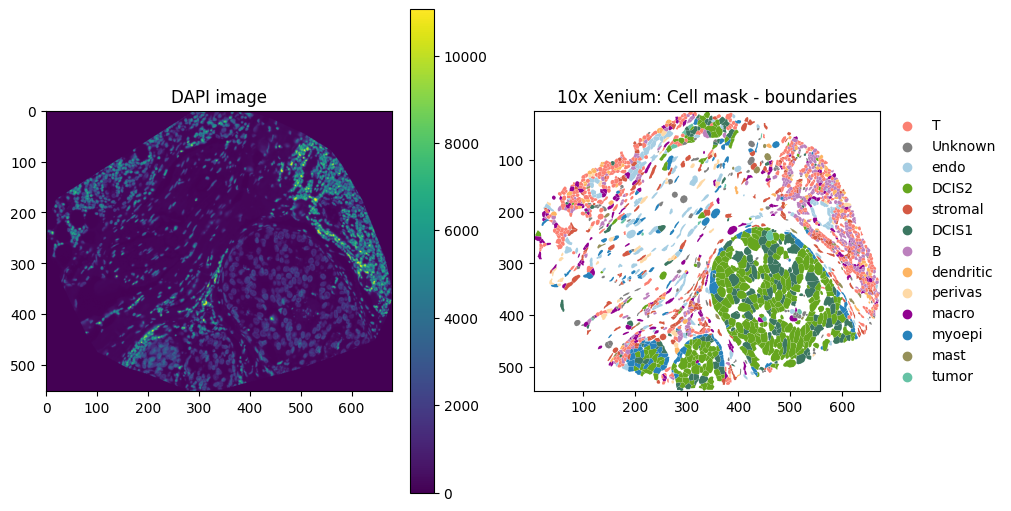

In [7]:
import matplotlib.pyplot as plt
import spatialdata_plot

axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

#Dapi image
sdata_10x_xenium.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot - Cell boundaries
sdata_10x_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_10x_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata_10x_xenium.pl.render_shapes("cell_boundaries", 
                                  color="transferred_celltype_plot", 
                                  palette=cols,
                                  groups=labels).pl.show(
    ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)

#### Compute positive and negative markers

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [8]:
tbl = sdata_10x_xenium.tables["table"]
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [9]:
markers = sq.sp.get_ref_markers(adata_ref, 
                      cell_type_column="celltype_major",
                      q_pos=0.95,
                      q_neg=0.1,
                      t=0.25)

The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

In [10]:
markers['B']['positive'][:20]

['ACP5',
 'ADAM28',
 'ADAM8',
 'ADGRG5',
 'AIM2',
 'AKAP11',
 'AMFR',
 'ANGPTL6',
 'ANKHD1',
 'ANKRD13A',
 'APOBEC3C',
 'APOBEC3D',
 'APOBEC3F',
 'ATP2B1',
 'BACH2',
 'BANK1',
 'BCL11A',
 'BCL2',
 'BLK',
 'BLNK']

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

In [11]:
markers['T']['positive'][25:30]

['CD27', 'CD28', 'CD3D', 'CD3E', 'CD3G']

#### Find mutually exclusive marker pairs

Mutually exclusive gene pairs are identified by scanning each cell type’s positive markers, keeping genes expressed in >20% of that type but <5% of all other cells and retaining only genes that satisfy this criterion for a single type. It then returns all cross-type combinations of these type-unique genes as (gene1, gene2) pairs.

In [16]:
mut_excl_marker_pairs = sq.sp.get_mut_excl_markers(adata_ref,
                                                   markers,
                                                   cell_type_column="celltype_major",
                                                   pos_threshold=0.2,
                                                   neg_threshold=0.05)

The mutually exclusive co-expression Rate (`MECR`) per gene pair in the spatial transcriptomics dataset can be calculated using `compute_MECR`. 

In [17]:
mecr = sq.sp.compute_MECR(sdata_10x_xenium,
                    gene_pairs=mut_excl_marker_pairs)

The median MECR is zero, however there are some ME gene pairs with MECR > 0. 

In [ ]:
import numpy as np

vals = list(mecr.values())
np.median([vals])

np.float64(0.0)

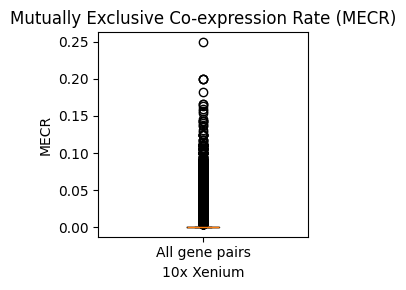

In [39]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["All gene pairs"])
plt.tight_layout()
plt.show()


We can additionally evalulate the distribution and proportion of gene pairs with non-zero MECR. 16% of the gene pairs found to be mutually exclusive in the reference scRNA-seq dataset have non-zero MECR with a median of 0.026.

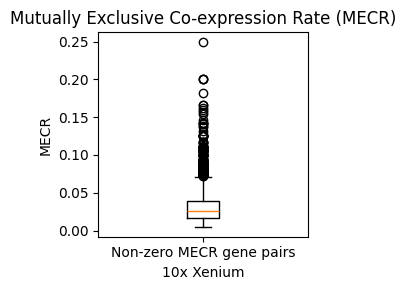

In [45]:
vals_nz = [x for x in vals if x > 0] #non zero

fig, ax = plt.subplots(figsize=(3, 3))
ax.boxplot([vals_nz], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["Non-zero MECR gene pairs"])
plt.tight_layout()
plt.show()

In [46]:
np.median(vals_nz)

np.float64(0.02631578947368421)

In [44]:
len(vals_nz)/len(vals)

0.16462793068297654